In [1]:
! pip install --upgrade pip
! pip install phate
! pip install hail
! pip install pyplink

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import numpy.ma as ma

from sklearn.manifold import TSNE
import phate
#import hail as hl
from pyplink import PyPlink

In [2]:
root = '/home/jupyter/workspaces/phaterepresentationsforvisualizationofgeneticdata/Data/'

demographic_data = pd.read_csv(os.path.join(root, 'Metadata/DemographicData.tsv'), sep='\t')
sire_data = pd.read_csv(os.path.join(root, 'Metadata/ProcessedSIRE.tsv'), sep='\t')
rye_data = pd.read_csv(os.path.join(root, 'Rye/V7/extractedChrAllPruned.ContinentalEstimates.6.Q'), sep='\t')
eigenvec = pd.read_csv(os.path.join(root, 'PCA_V7/extractedChrAllPruned.30.eigenvec'), header=0, sep='\t')

/tmp/ipykernel_238/3432072335.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  eigenvec = pd.read_csv(os.path.join(root, 'PCA_V7/extractedChrAllPruned.30.eigenvec'), header=0, sep='\t')


In [3]:
root = '/home/jupyter/workspaces/phaterepresentationsforvisualizationofgeneticdata/Data/'
plink_files = '1KGPHGDPAOU_V7/extractedChrAllPruned'

pedfile = PyPlink(os.path.join(root, plink_files))


In [4]:
all_samples = pedfile.get_fam()
all_samples.head()

,fid,iid,father,mother,gender,status
0,ACB,ACB1,0,0,0,-9
1,ACB,ACB2,0,0,0,-9
2,ACB,ACB3,0,0,0,-9
3,ACB,ACB4,0,0,0,-9
4,ACB,ACB5,0,0,0,-9


In [5]:
all_markers = pedfile.get_bim()
all_markers.head()

,chrom,pos,cm,a1,a2
snp,,,,,
chr1:826940:C:T,1,826940,0,T,C
chr1:833068:G:A,1,833068,0,A,G
chr1:839745:C:T,1,839745,0,T,C
chr1:946247:G:A,1,946247,0,A,G
chr1:946538:G:A,1,946538,0,A,G


In [6]:
#genotypes_array = np.zeros([pedfile.get_nb_samples(), pedfile.get_nb_markers()], dtype=np.int8)
#
#for i, (marker_id, genotypes) in tqdm.tqdm(enumerate(pedfile)):
#    genotypes_array[:,i] = genotypes
#
#np.save(os.path.join(root, plink_files) + '_raw_genotypes.npy', genotypes_array)
genotypes_array = np.load(os.path.join(root, plink_files) + '_raw_genotypes.npy')

In [7]:
# Get statistics for 1KGP+HGDP samples

KGPHGDP_subset = eigenvec['#FID'] != 'AOU'
KGPHGDP_genotypes = genotypes_array[KGPHGDP_subset]

In [8]:
KGPHGDP_genotypes = KGPHGDP_genotypes.astype(float)
KGPHGDP_genotypes[KGPHGDP_genotypes == -1] = np.nan # replace -1 with nan

In [9]:
scaled_KGPHGDP_genotypes = np.where(np.isnan(KGPHGDP_genotypes), 
         ma.array(KGPHGDP_genotypes, mask=np.isnan(KGPHGDP_genotypes)).mean(axis=0), 
         KGPHGDP_genotypes)

In [10]:
colmeans = scaled_KGPHGDP_genotypes.mean(0)
scaled_KGPHGDP_genotypes = scaled_KGPHGDP_genotypes - colmeans

In [11]:
# Run PCA on subset
from sklearn.decomposition import PCA

# Run PCA on the subset using scikit-learn
pca_obj = PCA(n_components=50)
pca_obj.fit(scaled_KGPHGDP_genotypes)  # Fit PCA on the subset

PCA(n_components=50)

In [12]:
pca_emb = pca_obj.transform(scaled_KGPHGDP_genotypes)

In [13]:
labels = all_samples[KGPHGDP_subset]['fid']

mapping_dict = {
    'YRI': ['YRI', 'forReferenceYRI', 'Yoruba'],
    'ESN': ['ESN', 'forReferenceESN'],
    'GWD': ['GWD', 'forReferenceGWD'],
    'LWK': ['LWK', 'forReferenceLWK'],
    'MSL': ['MSL', 'forReferenceMSL'],
    'ACB': ['ACB', 'forReferenceACB'],
    'ASW': ['ASW', 'forReferenceASW'],
    'IBS': ['IBS', 'forReferenceIBS'],
    'CEU': ['CEU', 'forReferenceCEU'],
    'GBR': ['GBR', 'forReferenceGBR'],
    'TSI': ['TSI', 'forReferenceTSI', 'forReferenceTuscan'],
    'FIN': ['FIN', 'forReferenceFIN'],
    'PJL': ['PJL', 'forReferencePJL'],
    'BEB': ['BEB', 'forReferenceBEB'],
    'GIH': ['GIH', 'forReferenceGIH'],
    'STU': ['STU', 'forReferenceSTU'],
    'ITU': ['ITU', 'forReferenceITU'],
    'CHB': ['CHB', 'forReferenceCHB'],
    'CHS': ['CHS', 'forReferenceCHS'],
    'CDX': ['CDX', 'forReferenceCDX'],
    'KHV': ['KHV', 'forReferenceKHV'],
    'JPT': ['JPT', 'forReferenceJPT', 'Japanese'],
    'MXL': ['MXL', 'forReferenceMXL'],
    'CLM': ['CLM', 'forReferenceCLM', 'Colombian', 'forReferenceColombian'],
    'PEL': ['PEL', 'forReferencePEL'],
    'PUR': ['PUR', 'forReferencePUR'],
    'Other': []}

# Identify labels that are not mapped
mapped_labels = {label for sublist in mapping_dict.values() for label in sublist}
unmapped_labels = [label for label in labels if label not in mapped_labels]
mapping_dict['Other'] = np.unique(np.array(unmapped_labels))

hue_order = ["Other", "YRI", "ESN", "GWD", "LWK", "MSL", "ACB",
    "ASW", "IBS", "CEU", "GBR", "TSI", "FIN",
    "PJL", "BEB", "GIH", "STU", "ITU", "CHB",
    "CHS", "CDX", "KHV", "JPT", "MXL", "CLM",
    "PEL", "PUR"]

# Create a reverse mapping for easier access
reverse_mapping = {v: k for k, values in mapping_dict.items() for v in values}

# Map the labels
remapped_labels = [reverse_mapping.get(label) for label in labels]

pop_pallette_1000G_coarse = {'EAS': 'blue',
                            'EUR': 'purple',
                            'AMR': 'red',
                            'AFR': 'green',
                            'SAS': 'orange'
                           }
label_order_1000G_fine = ['YRI', 'ESN', 'GWD', 'LWK', 'MSL', 'ACB', 'ASW',
                           'IBS',  'CEU', 'GBR', 'TSI', 'FIN',
                           'PJL', 'BEB', 'GIH', 'STU', 'ITU',
                           'CHB', 'CHS', 'CDX', 'KHV', 'JPT',
                           'MXL', 'CLM', 'PEL', 'PUR']
pop_colors=["#C7E9C0","#A1D99B","#74C476","#41AB5D","#238B45","#006D2C","#00441B",
            "#EFBBFF","#D896FF", "#D896FF", "#BE29EC","#800080",
            "#FEEDDE","#FDBE85","#FD8D3C","#E6550D",
            "#DEEBF7", "#DEEBF7","#9ECAE1","#008080","#0ABAB5","#08519C",
           "#BC544B","#E3242B","#E0115F","#900D09","#7E2811"]
pop_pallette_1000G_fine = {label:color for label,color in zip(label_order_1000G_fine, pop_colors)}
pop_pallette_1000G_fine["Other"] = "#808080" #"#D3D3D3"

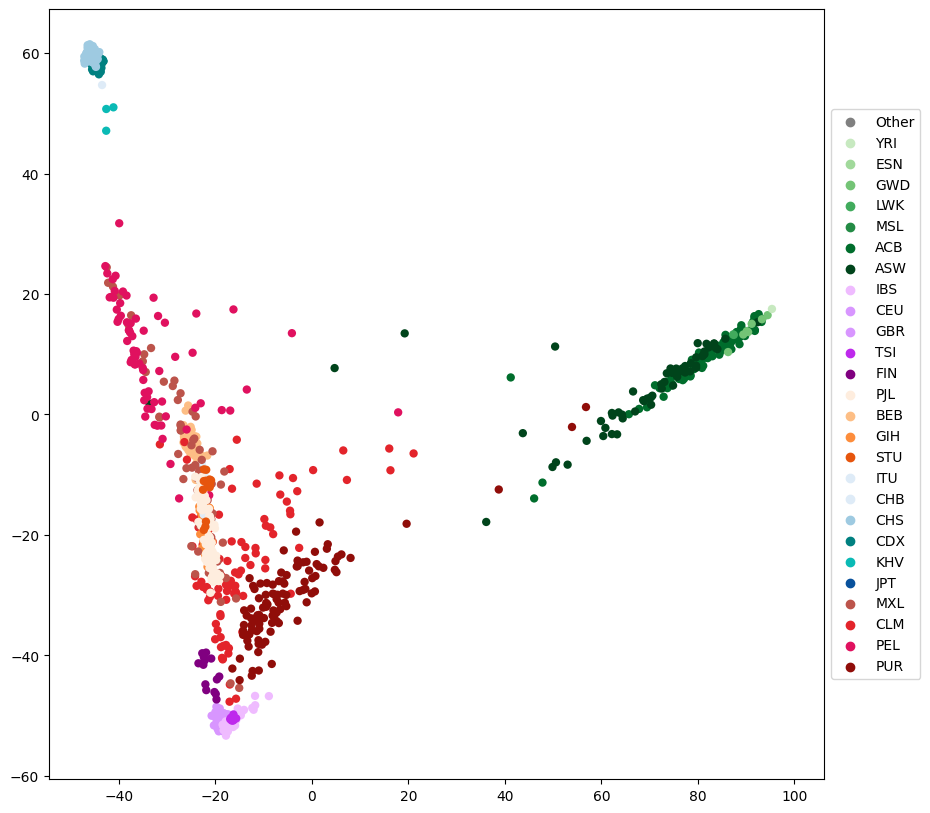

In [14]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(x=pca_emb[:,0], 
                y=pca_emb[:,1], palette=pop_pallette_1000G_fine,
                hue=labels, hue_order=hue_order, ax=ax, edgecolor='none')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [26]:
batch_size = 5000
num_samples = genotypes_array.shape[0]
i = 0
end = min(i + batch_size, num_samples)

to_process = genotypes_array[i:end].astype(float)
to_process[to_process == -1] = np.nan # replace -1 with nan

scaled_to_process = np.where(np.isnan(to_process), 
         ma.array(to_process, mask=np.isnan(to_process)).mean(axis=0), 
         to_process)

scaled_to_process = scaled_to_process - colmeans
pca_processed = pca_obj.transform(scaled_to_process)

In [60]:
# check projection
comb_data = np.vstack([pca_emb, pca_processed])
comb_labels = pd.concat([pd.Series(labels), pd.Series(['Other']*len(pca_processed))])

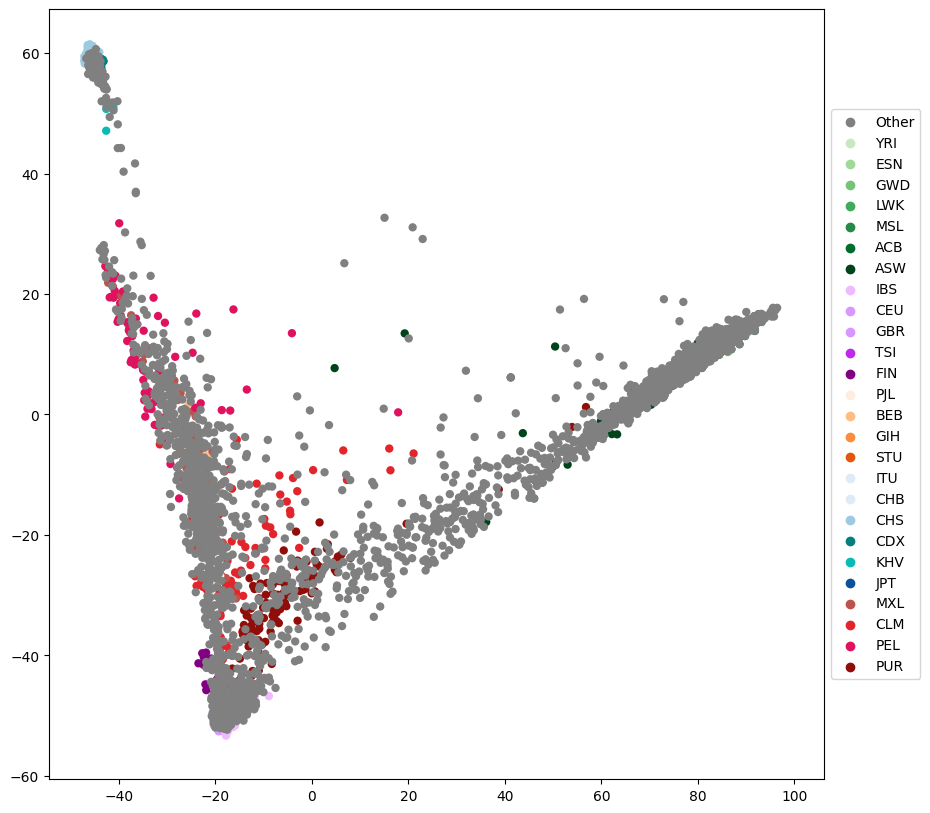

In [61]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(x=comb_data[:,0], 
                y=comb_data[:,1], palette=pop_pallette_1000G_fine,
                hue=comb_labels, hue_order=hue_order, ax=ax, edgecolor='none')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [64]:
# Collect AOU PCA embeddings
import h5py

num_samples = genotypes_array.shape[0]
with h5py.File(os.path.join(root, plink_files) + '_pca_proj_1kgphgdp.h5', 'w') as h5f:
    # Create a dataset to store transformed data (assuming 10 principal components)
    transformed_dataset = h5f.create_dataset('transformed_data', 
                                             shape=(num_samples, 50), 
                                             dtype='float32')

    # Chunk size for processing
    batch_size = 5000

    # Process in chunks of 2000 samples
    for i in tqdm.tqdm(range(0, num_samples, batch_size)):
        # Define the chunk end (handle case where the last chunk is < 5000)
        end = min(i + batch_size, num_samples)

        # Filter to get the batch of samples
        end = min(i + batch_size, num_samples)

        to_process = genotypes_array[i:end].astype(float)
        to_process[to_process == -1] = np.nan # replace -1 with nan

        scaled_to_process = np.where(np.isnan(to_process), 
                 ma.array(to_process, mask=np.isnan(to_process)).mean(axis=0), 
                 to_process)

        scaled_to_process = scaled_to_process - colmeans
        pca_processed = pca_obj.transform(scaled_to_process)

        # Save the transformed batch into the HDF5 file
        transformed_dataset[i:end, :] = pca_processed

        #print(f"Processed samples {i + 1} to {end}...")

# All transformed data is now saved in 'transformed_data.h5'
print("PCA transformation completed and saved to HDF5.")

100%|██████████| 63/63 [19:02<00:00, 18.14s/it]

PCA transformation completed and saved to HDF5.
